## Config BO

In [1]:
from langchain.prompts.prompt import PromptTemplate

initial_train = 1
initial_transfer_train=0
ask_K = 1
N=20
M=5
lambda_multi = 1
# model="gpt-3.5-instruct"
model="gpt-4o"
# model="sonnet"
# model = "gpt-4.1"
# model="gpt-3.5-turbo"
# model="gpt-4-turbo"
# model="gpr"

# Initialize Dataset

## synthetic dataset

In [2]:
dataset="mo_carb"

kwargs = dict(
    prefix=(
        "The following are correctly answered questions. "
        "Each answer is numeric and ends with ###\n"
        "Note: the Mo:sucrose ratio is a variable parameter "
        "and should not be assumed constant across experiments."
    ),
    prompt_template=PromptTemplate(
        input_variables=["x", "y", "y_name"],
        template="Q: What is the {y_name} of {x}?@@@\nA: {y}###",
    ),
    suffix="What is the {y_name} of {x}?@@@\nA:",
    x_formatter=lambda x: (
        f"experimental procedure: {x['procedure']}. "
        f"Observed phases — "
        f"Mo weight fraction: {x['Mo_wf']:.1f}%, sigma: {x['Mo_sigma']:.3f}%. "
        f"Mo2C weight fraction: {x['Mo2C_wf']:.1f}%, sigma: {x['Mo2C_sigma']:.3f}%. "
        f"MoC weight fraction: {x['MoC_wf']:.1f}%, sigma: {x['MoC_sigma']:.3f}%."
    ) if isinstance(x, dict) else x,
    y_name="cubic MoC weight fraction (%)",
    y_formatter=lambda y: f"{y:.1f}",
    x_name="synthesis procedure",
    model="gpt-4o",
    selector_k=5,
    temperature=0.7,
)

inv_system_message_path = "./BOICL_docs/inv_system_message_syn_data.txt"
system_message_path     = "./BOICL_docs/pred_system_message.txt"

path           = f"./out/{dataset}_{model}_{initial_train}_{ask_K}_{lambda_multi}_review1_comment2_v1.pkl"
path_ada       = f"./out/{dataset}_gpt-4o_ada_{initial_train}_{ask_K}_{lambda_multi}_v1.pkl"
path_bert      = f"./out/{dataset}_gpt-4o_bert_{initial_train}_{ask_K}_{lambda_multi}_v1.pkl"
pool_path      = "./dataset/data/moc_dataset.pkl"
bert_pool_path = "./dataset/data/moc_bert_pool.pkl"

In [3]:
print(repr(system_message_path))
print(repr(inv_system_message_path))

'./BOICL_docs/pred_system_message.txt'
'./BOICL_docs/inv_system_message_syn_data.txt'


### Load transfer learning dataset

In [3]:
import pandas as pd
import numpy as np

random_seed = 20
np.random.seed(random_seed)

t_data_path="top_10_similar_subset.csv"

t_data_path = "/Users/shane/repos/BO-LIFT/" + t_data_path
# transfer_data = pd.read_csv(t_data_path)
transfer_data = pd.read_csv("./dataset/C2_yield_meth_oxy_short_corrected.csv")

t_N = transfer_data.shape[0]
t_indexes = np.random.choice(transfer_data.shape[0], int(t_N), replace=False)
t_x_name = "prompt"
t_y_name = "completion"
len(t_indexes)

FileNotFoundError: [Errno 2] No such file or directory: './dataset/C2_yield_meth_oxy_short_corrected.csv'

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
from openai import OpenAI
import pandas as pd
import numpy as np
client = OpenAI()

model = "text-embedding-3-large"

def get_embeddings(texts, model=model, batch_size=100):
    all_embeddings = []
    cleaned_texts = [text.replace("n", " ") if isinstance(text, str) else "" for text in texts]
    for i in range(0, len(cleaned_texts), batch_size):
        batch = cleaned_texts[i: i + batch_size]
        embeddings_data = client.embeddings.create(input=batch, model=model).data
        all_embeddings.extend([embedding.embedding for embedding in embeddings_data])
    return np.array(all_embeddings)

small_data_path = "./dataset/data/bias_free_ocmdataset_p_comp.csv" 
large_data_path = "./dataset/data/C2_yield_meth_oxy_short_corrected.csv"

small_data = pd.read_csv(small_data_path)
large_data = pd.read_csv(large_data_path)

prompt_col = "prompt"
completion_col = "completion"

small_prompts = small_data[prompt_col].fillna("").tolist()
large_prompts = large_data[prompt_col].fillna("").tolist()

small_embeddings = get_embeddings(small_prompts)
large_embeddings = get_embeddings(large_prompts)

similarities = cosine_similarity(small_embeddings, large_embeddings)

selected_indices = set()
new_data_list = []

for i, small_prompt in tqdm(enumerate(small_prompts), total=len(small_prompts)):

    sorted_indices = np.argsort(similarities[i])[::-1]

    count = 0
    for index in sorted_indices:
        if index not in selected_indices:
            large_prompt = large_data.iloc[index][prompt_col]
            completion_text = large_data.iloc[index][completion_col]
            new_data_list.append({"prompt": large_prompt, "completion": completion_text})
            selected_indices.add(index)
            count += 1
        if count == 10:
            break

new_data = pd.DataFrame(new_data_list)
t_data_path = "top_10_similar_subset.csv"
new_data.to_csv(t_data_path, index=False)


# Setup

In [4]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

# from langchain.prompts.prompt import PromptTemplate
# import copy, cloudpickle
# import seaborn as sns

# import sys
# import os

# current_dir = os.getcwd()
# parent_dir = os.path.join(current_dir,'..')
# sys.path.insert(0, parent_dir)

# import boicl

# from dotenv import load_dotenv
# load_dotenv()
# transfer_data = ""

from langchain.prompts.prompt import PromptTemplate
import copy, cloudpickle
import sys
import os

# Load env FIRST before boicl tries to instantiate OpenAI client
from dotenv import load_dotenv
load_dotenv()

# Force local boicl over any PyPI install
sys.path.insert(0, "/Users/shane/repos/boicl_crystal_phase_isolation")

import boicl
print("boicl loaded from:", boicl.__file__)

/Users/shane/opt/anaconda3/envs/bo_icl/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


boicl loaded from: /Users/shane/repos/boicl_crystal_phase_isolation/boicl/__init__.py


In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import urllib.request

urllib.request.urlretrieve(
    "https://github.com/google/fonts/raw/main/ofl/ibmplexmono/IBMPlexMono-Regular.ttf",
    "IBMPlexMono-Regular.ttf",
)
fe = font_manager.FontEntry(fname="IBMPlexMono-Regular.ttf", name="plexmono")
font_manager.fontManager.ttflist.append(fe)
plt.rcParams.update(
    {
        "axes.facecolor": "#f5f4e9",
        "grid.color": "#AAAAAA",
        "axes.edgecolor": "#333333",
        "figure.facecolor": "#FFFFFF",
        "axes.grid": False,
        "axes.prop_cycle": plt.cycler("color", plt.cm.Dark2.colors),
        "font.family": fe.name,
        "figure.figsize": (3.5, 3.5 / 1.2),
        "ytick.left": True,
        "xtick.bottom": True,
    }
)


## Utils

In [6]:
# import uncertainty_toolbox as uct

def combine(s, l):
  '''Number of combinations of l elements with max = s'''
  return (s**l - (s-1)**(l))

def prob(s, l, n):
  '''Probability of getting a sample with max([x0,x1,...,xl]) = s where xi={0,n}'''
  return combine(s,l) * ((1/n)**l)

def expected_value_p(l, n):
  '''Expected value of max([x0,x1,...,xl]) where xi={0,n}'''
  E = [s * prob(s, l, n) for s in range(1,100+1)]
  return sum(E)

def expected_value_q(l, n, data):
  '''Expected value of max([x0,x1,...,xl]) where xi={0,n}'''
  quants = [data.quantile(i/100) for i in range(100+1)]
  # E = [(quants[s-1]) * prob(s, l, n) for s in range(1,100+1)]
  E = [((quants[s-1]+quants[s])/2) * prob(s, l, n) for s in range(1,100+1)]
  return sum(E)

from tenacity import (
    retry,
    stop_after_attempt,
    wait_random_exponential,
)

@retry(wait=wait_random_exponential(min=1, max=60), stop=stop_after_attempt(6))
def run_experiment(
    asktell, pool, raw_data, indexes, x_name, y_name, N=1, initial_train=1, ask_K=1,
    aq="random", start_index=0, calibrate=False, lambda_multi=1, system_message="",
    inv_system_message="", transfer_train=1, transfer=False, trans_data=None,
    t_indexes=None, row_to_x=None,   # ← added
):
    if row_to_x is None:
        row_to_x = lambda row: row[x_name]   # plain string fallback

    if aq == 'random_mean':
        return [(i, expected_value_q(i, 100, raw_data[y_name])) for i in range(1, N + initial_train)]

    point = []
    py = 0
    mod_std = 0
    counter = 0

    for i in indexes[:initial_train]:
        mean_value = np.mean(raw_data[y_name])
        y_list = raw_data[y_name]
        differences = np.abs(y_list - mean_value)
        mean_index = np.argmin(differences)

        x_dict = row_to_x(raw_data.iloc[mean_index])   # ← dict
        y_val = float(raw_data[y_name].iloc[mean_index])
        asktell.tell(x_dict, y_val)

        if counter == 0:
            i_best = y_val
        else:
            i_best = sorted(point, key=lambda i_points: i_points[-1])[-1][-3]

        point.append((x_dict, counter, i_best, y_val, y_val, mod_std))
        counter += 1

    if all([transfer, trans_data, t_indexes]):
        for j in t_indexes[:transfer_train]:
            asktell.tell(row_to_x(trans_data.iloc[j]), float(trans_data[y_name].iloc[j]))

    if calibrate:
        calibration_factor = 5.0
        asktell.set_calibration_factor(calibration_factor)

    # Build x as list of dicts to match pool contents
    x = [row_to_x(raw_data.iloc[i]) for i in range(len(raw_data))]   # ← dicts

    pool.reset()
    xi = x[start_index]                              # dict
    x.remove(xi)
    pool.choose(xi)
    yi = float(raw_data[raw_data[x_name] == xi["procedure"]][y_name].iloc[0])  # ← lookup by procedure string
    asktell.tell(xi, yi)
    best = yi
    point.append((xi, 1 + initial_train, best, yi))

    for i in range(1, N):
        if i == N - 1 and aq != "random":
            aq = "greedy"
        result = asktell.ask(
            pool,
            k=ask_K,
            aq_fxn=aq,
            _lambda=1.0,
            inv_filter=1,
            aug_random_filter=0,
            lambda_mult=lambda_multi,
            system_message=system_message,
            inv_system_message=inv_system_message,
        )
        px, _, py, std = result if len(result) == 4 else (*result, [0] * ask_K)
        for j in range(ask_K):
            xc = px[j]
            x.remove(xc)
            pool.choose(xc)
            y = float(raw_data[raw_data[x_name] == xc["procedure"]][y_name].iloc[0])
            asktell.tell(xc, y)
            best = max(y, best)
        point.append((xc, 1 + initial_train + i * ask_K, best, y))
        print(point)

    return point

    return point

In [7]:
import numpy as np
import pandas as pd


DATA_PATH = "/Users/shane/repos/boicl_crystal_phase_isolation/Mo-Carburization_Dataset_v2_labeled.xlsx"


def row_to_x(row: pd.Series) -> dict:
    """Convert a DataFrame row into the dict format expected by x_formatter.

    Maps dataset column names → optimizer dict keys:
        alpha_MoC_pct  → MoC_wf
        beta_Mo2C_pct  → Mo2C_wf
        Mo_pct         → Mo_wf

    Sigma columns do not exist in this dataset and are set to 0.0.
    If measurement replicates become available, replace the 0.0s with
    per-condition standard deviations.
    """
    return dict(
        procedure=row["procedure"],
        MoC_wf=row["alpha_MoC_pct"],
        MoC_sigma=0.0,
        Mo2C_wf=row["beta_Mo2C_pct"],
        Mo2C_sigma=0.0,
        Mo_wf=row["Mo_pct"],
        Mo_sigma=0.0,
    )


def get_dataset(data: str, M: int, initial_train: int):
    """Load and partition the Mo-carburization dataset.

    Parameters
    ----------
    data:
        Dataset key — pass ``"mo_carb"``.
    M:
        Number of points reserved for the optimisation loop.
    initial_train:
        Number of cold-start points drawn from the low-yield tail.

    Returns
    -------
    raw_data : pd.DataFrame
        Full dataset.  Pass rows through ``row_to_x`` before calling
        ``optimizer.tell(x, y)`` so the dict-branch of ``x_formatter``
        fires and phase context appears in every prompt.
    starts : pd.Index
        Row indices of the ``M + initial_train`` cold-start points.
    indexes : np.ndarray
        Full shuffled index array.
    x_name : str  →  ``"procedure"``  (DataFrame column for the input text)
    y_name : str  →  ``"alpha_MoC_pct"``  (DataFrame column for the target)
    row_to_x : callable
        Convenience re-export so callers don't need a separate import.

    Example
    -------
    >>> raw_data, starts, indexes, x_name, y_name, row_to_x = get_dataset("mo_carb", M, initial_train)
    >>> for idx in starts:
    ...     row = raw_data.loc[idx]
    ...     optimizer.tell(row_to_x(row), row[y_name])
    """
    match data:
        case "mo_carb":
            raw_data = pd.read_excel(DATA_PATH)
            raw_data = raw_data.sample(frac=1).reset_index(drop=True)
            x_name = "procedure"
            y_name = "alpha_MoC_pct"

        case _:
            raise ValueError(f"Unknown dataset: {data!r}")

    n_data = raw_data.shape[0]
    indexes = np.random.choice(n_data, n_data, replace=False)

    # alpha_MoC_pct is ~57 % zero-inflated; sample cold-start from the
    # bottom-100 rows so the model sees easy contrast early on.
    # M + initial_train must be ≤ 100 with this setting.
    starts = (
        raw_data
        .sort_values(by=y_name, ascending=True)
        .head(100)
        .sample(M + initial_train)
    )

    print(f"Dataset size:\n\t{n_data}")
    print(f"Start procedures:\n\t{starts[x_name].tolist()}")
    print(f"Start ys (alpha_MoC_pct):\n\t{starts[y_name].tolist()}")
    print(f"Start indexes:\n\t{starts.index.tolist()}\n")

    return raw_data, starts.index, indexes, x_name, y_name, row_to_x

In [8]:
def get_asktell(model: str, kwargs: dict = {}, pool: boicl.Pool = None, knn: int = 1):
    match model:
        case "mistral-7b-instruct:free":
            kwargs['model']="openrouter/mistralai/mistral-7b-instruct:free"
            return boicl.AskTellFewShotTopk(**kwargs)
        case "gemini-2.5-flash-preview":
            kwargs['model']="openrouter/google/gemini-2.5-flash-preview"
            return boicl.AskTellFewShotTopk(**kwargs)
        case "gpt-3.5-instruct":
            kwargs['model']="gpt-3.5-turbo-instruct"
            return boicl.AskTellFewShotTopk(**kwargs)
        case "gpt-3.5-turbo":
            kwargs['model']="gpt-3.5-turbo-0125"
            return boicl.AskTellFewShotTopk(**kwargs)
        case "gpt-4":
            kwargs['model']="gpt-4"
            return boicl.AskTellFewShotTopk(**kwargs)
        case "gpt-4.1":
            kwargs['model']="gpt-4.1"
            return boicl.AskTellFewShotTopk(**kwargs)
        case "gpt-4-turbo":
            kwargs['model']="gpt-4-0125-preview"
            return boicl.AskTellFewShotTopk(**kwargs)
        case "gpt-4o":
            kwargs['model']="gpt-4o"
            return boicl.AskTellFewShotTopk(**kwargs)
        case "gpt-4o-mini":
            kwargs['model']="gpt-4o-mini-2024-07-18"
            return boicl.AskTellFewShotTopk(**kwargs)
        case "haiku":
            kwargs['model']="claude-3-haiku-20240307"
            return boicl.AskTellFewShotTopk(**kwargs)
        case "sonnet":
            kwargs['model']="claude-3-5-sonnet-20240620"
            return boicl.AskTellFewShotTopk(**kwargs)
        case "opus":
            kwargs['model']="claude-3-opus-20240229"
            return boicl.AskTellFewShotTopk(**kwargs)
        case "davinci":
            kwargs['model']="davinci-002"
            return boicl.AskTellFewShotTopk(**kwargs)
        case "curie":
            kwargs['model']="text-curie-001"
            return boicl.AskTellFewShotTopk(**kwargs)
        case "gpr":
            kwargs['selector_k'] = 0
            kwargs['pool'] = pool if pool else None
            kwargs['n_components'] = 32
            return boicl.AskTellGPR(**kwargs)
        case "gpt-4o-bert":
            from boicl.bert_ask_tell import BertAskTellFewShotTopk
            kwargs['model'] = "gpt-4o"
            return BertAskTellFewShotTopk(
                embedding_cache="./dataset/data/matscibert_embeddings.npz",
                bert_model_name="m3rg-iitd/matscibert",
                **kwargs,
            )
        case _:
            raise ValueError("Unknown model")
       

In [ ]:
import numpy as np
import pandas as pd
import torch
from transformers import BertTokenizer, BertModel

# ── Load procedures ───────────────────────────────────────────────────
df = pd.read_excel("/Users/shane/repos/boicl_crystal_phase_isolation/Mo-Carburization_Dataset_v2_labeled.xlsx")
procedures = df["procedure"].tolist()

# ── Load MatSciBERT (cached locally) ─────────────────────────────────
device = "cpu"
tokenizer = BertTokenizer.from_pretrained("m3rg-iitd/matscibert")
model = BertModel.from_pretrained("m3rg-iitd/matscibert", add_pooling_layer=False).eval()

# ── Test single embed ─────────────────────────────────────────────────
enc = tokenizer(procedures[0], return_tensors="pt", truncation=True, max_length=512, padding=False)
with torch.no_grad():
    out = model(**enc)
emb = out.last_hidden_state.squeeze(0).mean(0).numpy()
print("test embed shape:", emb.shape)

# ── Embed one at a time ───────────────────────────────────────────────
embeddings = []
for i, proc in enumerate(procedures):
    enc = tokenizer(proc, return_tensors="pt", truncation=True,
                    max_length=512, padding=False)
    with torch.no_grad():
        out = model(**enc)
    emb = out.last_hidden_state.squeeze(0).mean(0).numpy()
    embeddings.append(emb)
    if i % 100 == 0:
        print(f"{i}/{len(procedures)}")

embeddings = np.vstack(embeddings)

import os
os.makedirs("./dataset/data", exist_ok=True)
np.savez(
    "./dataset/data/matscibert_embeddings.npz",
    procedures=np.array(procedures),
    embeddings=embeddings,
)
print("Done.")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1198.69it/s, Materializing param=encoder.layer.11.output.dense.weight]              
BertModel LOAD REPORT from: m3rg-iitd/matscibert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
import os
print(os.path.exists("./dataset/data/matscibert_embeddings.npz"))

True


In [12]:
import os
os.makedirs("./dataset/data", exist_ok=True)

np.savez(
    "/Users/shane/repos/boicl_crystal_phase_isolation/matbert_embeddings.npz",
    procedures=np.array(procedures),
    embeddings=embeddings,
)
print("Done.")

NameError: name 'procedures' is not defined

In [13]:
# enc = tokenizer(procedures[0], return_tensors="pt", truncation=True, max_length=512, padding=False)
# with torch.no_grad():
#     out = model(**enc)
# print(out.last_hidden_state.shape)
import os
import numpy as np

data = np.load("/Users/shane/repos/boicl_crystal_phase_isolation/matbert_embeddings.npz", allow_pickle=True)
print(data["procedures"].shape)
print(data["embeddings"].shape)

raw_data, starts, indexes, x_name, y_name, row_to_x = get_dataset(dataset, M=M, initial_train=initial_train)

(2500,)
(1521, 768)
Dataset size:
	2500
Start procedures:
	['Dissolve 1 g ammonium heptamolybdate tetrahydrate in 6 mL DI water. Dissolve 1 g sucrose in 1.5 mL DI water. Combine; stir 15 min at 300 RPM; dry at 120 °C in air for 24 hr. Crush. Load 1 g into crucible; ramp 15 °C/min to 440.8 °C, hold 15.67 hr under 30 ccm H2. Cool under 30 ccm N2 to <30 °C. Passivate under 30 ccm 1% O2/N2 for 2 hr.', 'Dissolve 1 g ammonium heptamolybdate tetrahydrate in 6 mL DI water. Dissolve 1 g sucrose in 1.5 mL DI water. Combine; stir 15 min at 300 RPM; dry at 120 °C in air for 24 hr. Crush. Load 1 g into crucible; ramp 15 °C/min to 542.9 °C, hold 0.00 hr under 30 ccm H2. Cool under 30 ccm N2 to <30 °C. Passivate under 30 ccm 1% O2/N2 for 2 hr.', 'Dissolve 1 g ammonium heptamolybdate tetrahydrate in 6 mL DI water. Dissolve 1 g sucrose in 1.5 mL DI water. Combine; stir 15 min at 300 RPM; dry at 120 °C in air for 24 hr. Crush. Load 1 g into crucible; ramp 15 °C/min to 798.0 °C, hold 22.04 hr under 30 cc

# BayesOpt experiments

## Run BO

In [14]:
from boicl.bert_pool import BertPool

def read_bkp(path, pool_path, indexes, kwargs, use_bert=False):
    if os.path.exists(pool_path):
        with open(pool_path, "rb") as f:
            pool = cloudpickle.load(f)
        pool.reset()
    else:
        x = [row_to_x(raw_data.iloc[i]) for i in indexes]
        if use_bert:
            pool = BertPool(list(x), formatter=kwargs['x_formatter'])
        else:
            pool = boicl.Pool(list(x), formatter=kwargs['x_formatter'])

    if os.path.exists(path):
        bayesOpts = cloudpickle.load(open(path, "rb"))
    else:
        bayesOpts = {}

    return bayesOpts, pool   # ← was commented out

system_message = open(system_message_path).read() if os.path.exists(system_message_path) else ""
inv_system_message = open(inv_system_message_path).read() if os.path.exists(inv_system_message_path) else ""

bayesOpts, pool      = read_bkp(path_ada,  pool_path,      indexes, kwargs, use_bert=False)
bayesOpts, bert_pool = read_bkp(path_bert, bert_pool_path, indexes, kwargs, use_bert=True)

✅ Loaded cache (10,276 embeddings).


In [ ]:
# import warnings
# warnings.filterwarnings('ignore', message='Changing the sparsity structure of a csr_matrix is expensive.*')
# warnings.filterwarnings('ignore', message='Input data is not contained to the unit cube.*')
# warnings.filterwarnings('ignore', message='Input data is not standardized.*')
# warnings.filterwarnings('ignore', message="Keyword arguments .* will be ignored because they are not allowed parameters for function .*", category=UserWarning)
# warnings.filterwarnings('ignore', message="Unexpected type for token usage: <class 'NoneType'>", category=UserWarning)

# for aq in [ 
#     'greedy', 
#     'random_mean',
#     'random',
#     # 'expected_improvement',
#     # 'log_expected_improvement',
#     # 'probability_of_improvement', 
#     ]:
#     print(aq, "start:", end=" ")
#     points = []
#     for i in range(M):
#         print(i, end=",  ")
        
#         point = run_experiment(
#             get_asktell(model, kwargs=kwargs), #, pool=boicl.Pool(list(pool.sample(500)))), #copy.deepcopy(asktell),
#             pool, # copy.deepcopy(pool)
#             raw_data,
#             indexes=indexes,
#             x_name=x_name,
#             y_name=y_name,
#             N=N,
#             aq=aq,
#             start_index=starts[i+initial_train],
#             calibrate=True,
#             initial_train=initial_train,
#             ask_K=ask_K,
#             lambda_multi=lambda_multi,
#             system_message=system_message,
#             inv_system_message=inv_system_message,
#             transfer_train=initial_transfer_train,
#             transfer=False,
#             trans_data=None,
#             t_indexes=None,
#             row_to_x=row_to_x,
#             )
#         points.append(point)
#     points = np.array(points)
#     bayesOpts[aq] = points
#     print(aq, "done")
#     # if isinstance(asktell, boicl.AskTellGPR):
#     #     asktell.save_cache("GPR_ada_embed_cache.csv")
#     cloudpickle.dump(bayesOpts, open(path, "wb"))
# cloudpickle.dump(bayesOpts, open(path, "wb"))
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning, message='BertAskTellFewShotTopk.*')
from boicl.bert_pool import BertPool
warnings.filterwarnings('ignore', message='Changing the sparsity structure of a csr_matrix is expensive.*')
warnings.filterwarnings('ignore', message='Input data is not contained to the unit cube.*')
warnings.filterwarnings('ignore', message='Input data is not standardized.*')
warnings.filterwarnings('ignore', message="Keyword arguments .* will be ignored because they are not allowed parameters for function .*", category=UserWarning)
warnings.filterwarnings('ignore', message="Unexpected type for token usage: <class 'NoneType'>", category=UserWarning)
for experiment_model, experiment_pool, experiment_path in [
    ("gpt-4o-bert", bert_pool, path_bert),
    ("gpt-4o",      pool,      path_ada),
    
]:
    print(f"\n=== {experiment_model} ===")
    bayesOpts = cloudpickle.load(open(experiment_path, "rb")) if os.path.exists(experiment_path) else {}

    for aq in ["random", "expected_improvement"]:
        print(aq, "start:", end=" ")
        points = []
        for i in range(M):
            print(i, end=",  ")
            point = run_experiment(
                get_asktell(experiment_model, kwargs=kwargs.copy()),
                experiment_pool,a
                raw_data,
                indexes=indexes,
                x_name=x_name,
                y_name=y_name,
                N=N,
                aq=aq,
                start_index=starts[i + initial_train],
                calibrate=True,
                initial_train=initial_train,
                ask_K=ask_K,
                lambda_multi=lambda_multi,
                system_message=system_message_path,
                inv_system_message=inv_system_message_path,
                transfer_train=initial_transfer_train,
                transfer=False,
                trans_data=None,
                t_indexes=None,
                row_to_x=row_to_x,
            )
            points.append(point)

        points = np.array(points, dtype=object)
        bayesOpts[aq] = points
        print(aq, "done")
        cloudpickle.dump(bayesOpts, open(experiment_path, "wb"))


=== gpt-4o-bert ===
random start: 0,  [({'procedure': 'Dissolve 1 g ammonium heptamolybdate tetrahydrate in 6 mL DI water. Dissolve 1 g sucrose in 1.5 mL DI water. Combine; stir 15 min at 300 RPM; dry at 120 °C in air for 24 hr. Crush. Load 1 g into crucible; ramp 15 °C/min to 818.4 °C, hold 3.43 hr under 30 ccm H2. Cool under 30 ccm N2 to <30 °C. Passivate under 30 ccm 1% O2/N2 for 2 hr.', 'MoC_wf': 2.406, 'MoC_sigma': 0.0, 'Mo2C_wf': 83.176, 'Mo2C_sigma': 0.0, 'Mo_wf': 1.246, 'Mo_sigma': 0.0}, 0, 2.406, 2.406, 2.406, 0), ({'procedure': 'Dissolve 1 g ammonium heptamolybdate tetrahydrate in 6 mL DI water. Dissolve 1 g sucrose in 1.5 mL DI water. Combine; stir 15 min at 300 RPM; dry at 120 °C in air for 24 hr. Crush. Load 1 g into crucible; ramp 15 °C/min to 849.0 °C, hold 18.61 hr under 30 ccm H2. Cool under 30 ccm N2 to <30 °C. Passivate under 30 ccm 1% O2/N2 for 2 hr.', 'MoC_wf': 0.0, 'MoC_sigma': 0.0, 'Mo2C_wf': 11.406, 'Mo2C_sigma': 0.0, 'Mo_wf': 87.914, 'Mo_sigma': 0.0}, 2, 0.0, 

In [18]:
import os
print(os.listdir("/Users/shane/repos/boicl_crystal_phase_isolation/boicl"))

['aqfxns.py', 'design_space.py', '.DS_Store', 'version.py', 'bert_ask_tell.py', 'call_design_space.py', 'datasets', '__init__.py', '__pycache__', 'asktellFinetuning.py', 'llm_model.py', 'asktellRidgeRegression.py', 'bert_pool.py', 'asktell.py', 'pool.py', 'tool.py', 'asktellGPR.py', 'asktellNearestNeighbor.py']


In [21]:
path

'./out/mo_carb_gpt-4o_2_1_1_review1_comment2_v1.pkl'

In [ ]:
for key, value in d.items():
    print(key, value.shape)

In [16]:
import os
for p in [path_ada, path_bert]:
    if os.path.exists(p):
        os.remove(p)
        print(f"Deleted {p}")

Deleted ./out/mo_carb_gpt-4o_ada_1_1_1_v1.pkl
Deleted ./out/mo_carb_gpt-4o_bert_1_1_1_v1.pkl


## BayesOpt Plot

### Utils

In [27]:
import numpy as np

def plot_BO(ax, data_file, title, data, axis_name,
            lim=None, label=False, M=1, show_low=True):

    d = data_file

    def split_runs(arr, step_idx=1):
        arr = np.asarray(arr, dtype=object)
        
        # (M, T) — each row is one complete run
        if arr.ndim == 2:
            return [arr[i] for i in range(arr.shape[0])]
        
        # (T,) — single flat run
        return [arr]

    def plot_runs(arr, color, alpha=0.2):
        for r in split_runs(arr)[:M]:
            x = [int(row[1]) for row in r]
            y = [float(row[2]) for row in r]
            ax.plot(x, y, color=color, alpha=alpha)

    def plot_mean_with_band(arr, color, lbl):
        runs = split_runs(arr)
        if not runs:
            return
        if len(runs) == 1:
            r = runs[0]
            x = [int(row[1]) for row in r]
            y = [float(row[2]) for row in r]
            ax.plot(x, y, color=color, label=lbl)
            return
        min_len = min(len(r) for r in runs)
        stack = np.stack([r[:min_len] for r in runs], axis=0)
        x = stack[:, :, 1].astype(int).mean(axis=0)
        y = stack[:, :, 2].astype(float)
        ax.plot(x, y.mean(axis=0), color=color, label=lbl)
        ax.fill_between(x, y.min(axis=0), y.max(axis=0), color=color, alpha=0.1)

    # ── BO curves ────────────────────────────────────────────────────
    for key, color, name in [
        ("greedy",                    "C2", "Greedy"),
        ("upper_confidence_bound",    "C3", "UCB"),
        ("expected_improvement",      "C1", "EI"),
        ("log_expected_improvement",  "C5", "Log EI"),
        ("probability_of_improvement","C4", "POI"),
        ("random",                    "C8", "Random"),
    ]:
        if key not in d:
            continue
        plot_runs(d[key], color)
        plot_mean_with_band(d[key], color, name if label else None)

    # ── Random mean ───────────────────────────────────────────────────
    if "random_mean" in d:
        rm = np.asarray(d["random_mean"], dtype=object)
        if rm.ndim == 3:
            rm = rm[0]
        if rm.ndim == 1:
            rm = np.asarray(list(rm), dtype=object)
        try:
            x = np.array([float(np.asarray(row[0]).reshape(-1)[0]) for row in rm])
            y = np.array([float(np.asarray(row[1]).reshape(-1)[0]) for row in rm])
            mask = np.isfinite(x) & np.isfinite(y)
            x, y = x[mask], y[mask]
            if x.size:
                ax.plot(x, y, color="gray", linestyle="dashed", linewidth=2,
                        label="Random Mean" if label else None)
        except Exception:
            pass

    # ── Reference lines ───────────────────────────────────────────────
    ax.axhline(data.max(),           linestyle="--", color="C15")
    ax.text(ax.get_xlim()[1]+1, data.max(),            "max",  va="center")
    ax.axhline(data.quantile(0.99),  linestyle="--", color="C14")
    ax.text(ax.get_xlim()[1]+1, data.quantile(0.99),   "99%",  va="center")
    ax.axhline(data.quantile(0.95),  linestyle="--", color="C13")
    ax.text(ax.get_xlim()[1]+1, data.quantile(0.95),   "95%",  va="center")
    ax.axhline(data.mean(),          linestyle="--", color="C12")
    ax.text(ax.get_xlim()[1]+1, data.mean(),            "mean", va="center")

    if show_low:
        ax.axhline(data.quantile(0.05), linestyle="--", color="C11")
        ax.text(ax.get_xlim()[1]+1, data.quantile(0.05), "5%",  va="center")
        ax.axhline(data.min(),          linestyle="--", color="C10")
        ax.text(ax.get_xlim()[1]+1, data.min(),           "min", va="center")

    ax.set_title(title)
    ax.set_xlabel("Number of samples")
    ax.set_ylabel(f"Measured {axis_name}")
    if lim:
        ax.set_ylim(lim)
    ax.set_xlim(0, 30)

In [26]:
key = [k for k in bayesOpts.keys() if k != "random_mean"][0]
sample = bayesOpts[key]
print(type(sample), np.asarray(sample, dtype=object).shape)
print(type(sample[0]))
print(sample[0])

<class 'numpy.ndarray'> (1, 12)
<class 'numpy.ndarray'>
[({'procedure': 'Dissolve 1 g ammonium heptamolybdate tetrahydrate in 6 mL DI water. Dissolve 1 g sucrose in 1.5 mL DI water. Combine; stir 15 min at 300 RPM; dry at 120 °C in air for 24 hr. Crush. Load 1 g into crucible; ramp 15 °C/min to 818.4 °C, hold 3.43 hr under 30 ccm H2. Cool under 30 ccm N2 to <30 °C. Passivate under 30 ccm 1% O2/N2 for 2 hr.', 'MoC_wf': 2.406, 'MoC_sigma': 0.0, 'Mo2C_wf': 83.176, 'Mo2C_sigma': 0.0, 'Mo_wf': 1.246, 'Mo_sigma': 0.0}, 0, 2.406, 2.406, 2.406, 0)
 ({'procedure': 'Dissolve 1 g ammonium heptamolybdate tetrahydrate in 6 mL DI water. Dissolve 1 g sucrose in 1.5 mL DI water. Combine; stir 15 min at 300 RPM; dry at 120 °C in air for 24 hr. Crush. Load 1 g into crucible; ramp 15 °C/min to 818.4 °C, hold 3.43 hr under 30 ccm H2. Cool under 30 ccm N2 to <30 °C. Passivate under 30 ccm 1% O2/N2 for 2 hr.', 'MoC_wf': 2.406, 'MoC_sigma': 0.0, 'Mo2C_wf': 83.176, 'Mo2C_sigma': 0.0, 'Mo_wf': 1.246, 'Mo_sigma

### Paper figures

/var/folders/gn/t7lkvwjx45l9y1jzv5lphf2h0000gn/T/ipykernel_50959/2359265482.py:20: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) IBM Plex Mono.
  plt.savefig("./out/figs/mo_carb_bo.png", dpi=300, bbox_inches='tight')
/Users/shane/opt/anaconda3/envs/bo_icl/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) IBM Plex Mono.
  fig.canvas.print_figure(bytes_io, **kw)


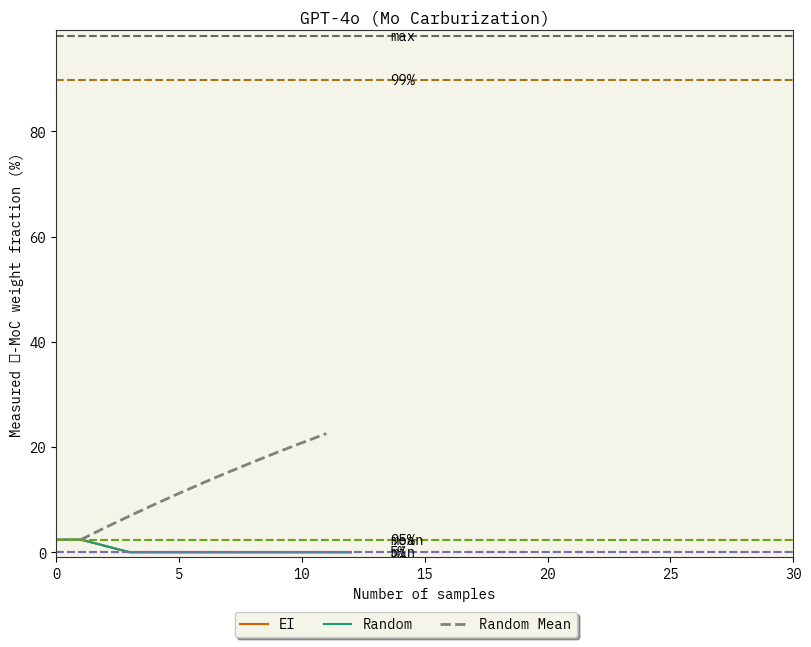

In [28]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(8, 6), constrained_layout=True)

lim = (raw_data[y_name].min() - 1, raw_data[y_name].max() + 1)

os.makedirs("./out/figs", exist_ok=True)

plot_BO(
    axs,
    bayesOpts,
    title=f"GPT-4o (Mo Carburization)",
    data=raw_data[y_name],
    axis_name="α-MoC weight fraction (%)",
    lim=lim,
    label=True,
    M=M,
    show_low=True,
)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0), fancybox=True, shadow=True, ncol=6)
plt.savefig("./out/figs/mo_carb_bo.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
d_curie = cloudpickle.load(open("./out/ocm_curie_12744_1_1_16nr.pkl", "rb"))
d_davinci = cloudpickle.load(open("./out/C2_davinci2_12744_1_16nr.pkl", "rb"))
d_gpt4 = cloudpickle.load(open("./out/ocm_GPT-4_12744_0_s.pkl", "rb"))
d_gpr = cloudpickle.load(open("./out/C2_gpr_12744_1_16nr.pkl", "rb"))

print(d_curie['expected_improvement'][:, -1, 2].astype(float))
best_curie = d_curie['expected_improvement'][:, :, 2].astype(float).mean(axis=0)[-1]
print(f"Curie is top{np.sum(raw_data[y_name] > best_curie)}: {best_curie}")

print(d_davinci['expected_improvement'][:, -1, 2].astype(float))
best_davinci = d_davinci['expected_improvement'][:, :, 2].astype(float).mean(axis=0)[-1]
print(f"DaVinci is top{np.sum(raw_data[y_name] > best_davinci)}: {best_davinci}")

print(d_gpt4['expected_improvement'][:, -1, 2].astype(float))
best_gpt4 = d_gpt4['expected_improvement'][:, :, 2].astype(float).mean(axis=0)[-1]
print(f"Gpt4 is top{np.sum(raw_data[y_name] > best_gpt4)}: {best_gpt4}")

print(d_gpr['expected_improvement'][:, -1, 2].astype(float))
best_gpr = d_gpr['expected_improvement'][:, :, 2].astype(float).mean(axis=0)[-1]
print(f"GPR is top{np.sum(raw_data[y_name] > best_gpr)}: {best_gpr}")

sns.histplot(raw_data[y_name])
# print(np.sum(raw_data[y_name] > best))
plt.xlabel("measured C$_2$ yield")
plt.axvline(best_curie, color='C4', linestyle='--', label="Curie")
plt.axvline(best_davinci, color='C1', linestyle='--', label="Davinci")
plt.axvline(best_gpt4, color='C2', linestyle='--', label="GPT4")
plt.axvline(best_gpr, color='C3', linestyle='--', label="GPR")
plt.legend()
plt.tight_layout()
plt.savefig(f"./out/figs/ocm_hist", dpi=300, bbox_inches='tight')
plt.show()




In [ ]:
import scipy.stats as stats

d_gpt35 = cloudpickle.load(open("./out/ocm_gpt-3.5-turbo_1_1_0.1.pkl", "rb"))
d_gpt4o = cloudpickle.load(open("./out/ocm_gpt-4o_1_1_0.1.pkl", "rb"))
d_gpr   = cloudpickle.load(open("./out/ocm_gpr_5_1_0.1.pkl", "rb"))

v_gpt35 = d_gpt35['upper_confidence_bound'][:, :, 2].astype(float)
v_gpt4o = d_gpt4o['upper_confidence_bound'][:, :, 2].astype(float)
v_gpr   = d_gpr['upper_confidence_bound'][:, :, 2].astype(float)

stat = stats.ttest_ind(v_gpt35, v_gpr)
plt.plot([i for i in range(1,31)], stat.pvalue, label="gpt-3.5-turbo vs GPR")
stat = stats.ttest_ind(v_gpt4o, v_gpr)
plt.plot([i for i in range(1,31)], stat.pvalue, label="gpt-4o vs GPR")
stat = stats.ttest_ind(v_gpt35, v_gpt4o)
plt.plot([i for i in range(1,31)], stat.pvalue, label="gpt-3.5-turbo vs gpt-4o")
plt.xlabel("Iteration")
plt.ylabel("p-value")
plt.xticks(np.arange(0, 31, 5))
plt.axhline(0.05, color='r', linestyle='--')
plt.tight_layout()
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.55), ncol=1)
plt.savefig(f"./out/figs/ocm_bo_pvalue", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
d_davinci = cloudpickle.load(open("./out/sol_davinci_100.pkl", "rb"))
d_gpt4 = cloudpickle.load(open("./out/sol_gpt4_100.pkl", "rb"))
d_gpr = cloudpickle.load(open("./out/sol_GPR_100.pkl", "rb"))

print(d_davinci['expected_improvement'][:, -1, 2].astype(float))
best_davinci = d_davinci['expected_improvement'][:, :, 2].astype(float).mean(axis=0)[-1]
print(f"DaVinci is top{np.sum(raw_data[y_name] > best_davinci)}: {best_davinci}")

print(d_gpt4['expected_improvement'][:, -1, 2].astype(float))
best_gpt4 = d_gpt4['expected_improvement'][:, :, 2].astype(float).mean(axis=0)[-1]
print(f"Gpt4 is top{np.sum(raw_data[y_name] > best_gpt4)}: {best_gpt4}")

print(d_gpr['expected_improvement'][:, -1, 2].astype(float))
best_gpr = d_gpr['expected_improvement'][:, :, 2].astype(float).mean(axis=0)[-1]
print(f"GPR is top{np.sum(raw_data[y_name] > best_gpr)}: {best_gpr}")

sns.histplot(raw_data[y_name])
plt.axvline(best_davinci, color='C1', linestyle='--', label="Davinci")
plt.axvline(best_gpt4, color='C2', linestyle='--', label="GPT4")
plt.axvline(best_gpr, color='C3', linestyle='--', label="GPR")
plt.legend()
plt.savefig(f"figs/hist_sol", dpi=300, bbox_inches='tight')
plt.show()

print(raw_data[raw_data[y_name] > best_davinci-0.08])



### C2

In [ ]:
# np.random.seed(88)

# data_path = "./dataset/data/12744_ocm_dataset.csv"
# raw_data = pd.read_csv(data_path, sep=";")
# # raw_data = raw_data.sample(frac=1).reset_index(drop=True)
# # raw_data['completion'] = - raw_data['completion']

# x_name = "prompt"
# y_name = "completion"

In [ ]:
raw_data, starts, indexes, x_name, y_name = get_dataset("ocm", M=5)

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(16,4), constrained_layout=True)
# for ax in axs.flat:
#     ax.set_aspect(0.6)

lim=(0,8)
raw_data = pd.read_csv("dataset/data/1180_ocm_dataset.csv", sep=";")
plot_BO(axs[0], "./out/C2_davinci_1180_1_tree.pkl","20", 
         raw_data[y_name], "C$_2$ yield", lim, label=True, data_file_random="./out/C2 - random - 1180.pkl")

lim=(0,10)
raw_data = pd.read_csv("dataset/data/2950_ocm_dataset.csv", sep=";")
plot_BO(axs[1], "./out/C2_davinci_2950_1_tree.pkl","50",
         raw_data[y_name], "C$_2$ yield", lim, label=False, data_file_random="./out/C2 - random - 2950.pkl")

lim=(0,25)
raw_data = pd.read_csv("dataset/data/5900_ocm_dataset.csv", sep=";")
plot_BO(axs[2], "./out/C2_davinci_5900_1_tree.pkl", "100",
         raw_data[y_name], "C$_2$ yield", lim, label=False, data_file_random="./out/C2 - random - 5900.pkl")

lim=(0,25)
raw_data = pd.read_csv("dataset/data/12744_ocm_dataset.csv", sep=";")
plot_BO(axs[3], "./out/C2_davinci_12744_1_tree_2.pkl", "216",
         raw_data[y_name], "C$_2$ yield", lim, label=False, data_file_random="./out/C2 - random - 12744.pkl")

fig.suptitle("TreePool with davinci")
fig.legend(loc='upper center', bbox_to_anchor=(0.5,0),
          fancybox=True, shadow=True, ncol=6)
plt.savefig(f"figs/BO_C2", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
pools = [
    './out/C2_davinci_1180_1_tree.pkl',
    './out/C2_davinci_2950_1_tree.pkl',
    './out/C2_davinci_5900_1_tree.pkl',
    './out/C2_davinci_12744_1_tree.pkl',
]
for p in pools:
    print(p)
    d = cloudpickle.load(open(p, "rb"))
    for run in d['upper_confidence_bound'][:, :, 0]:
        print([r[14:r.find(",")] for r in run])
    
    print()

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(16,4), constrained_layout=True)
# for ax in axs.flat:
#     ax.set_aspect(0.6)

lim=(0,8)
raw_data = pd.read_csv("dataset/data/1180_ocm_dataset.csv", sep=";")
plot_BO(axs[0], "./out/C2_davinci_1180_1_16hh.pkl","20", 
         raw_data[y_name], "C$_2$ yield", lim, label=True, data_file_random="./out/C2 - random - 1180.pkl")

lim=(0,10)
raw_data = pd.read_csv("dataset/data/2950_ocm_dataset.csv", sep=";")
plot_BO(axs[1], "./out/C2_davinci_2950_1_16hh.pkl","50",
         raw_data[y_name], "C$_2$ yield", lim, label=False, data_file_random="./out/C2 - random - 2950.pkl")

lim=(0,25)
raw_data = pd.read_csv("dataset/data/5900_ocm_dataset.csv", sep=";")
plot_BO(axs[2], "./out/C2_davinci_5900_1_16hh.pkl", "100",
         raw_data[y_name], "C$_2$ yield", lim, label=False, data_file_random="./out/C2 - random - 5900.pkl")

lim=(0,25)
raw_data = pd.read_csv("dataset/data/12744_ocm_dataset.csv", sep=";")
plot_BO(axs[3], "./out/C2_davinci_12744_1_16hh.pkl", "216",
         raw_data[y_name], "C$_2$ yield", lim, label=False, data_file_random="./out/C2 - random - 12744.pkl")
         

fig.suptitle("Subpool of 16 with half random samples with davinci")
fig.legend(loc='upper center', bbox_to_anchor=(0.5,0),
          fancybox=True, shadow=True, ncol=6)
plt.savefig(f"figs/BO_C2", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
pools = [
    './out/C2_davinci_1180_1_16hh.pkl',
    './out/C2_davinci_2950_1_16hh.pkl',
    './out/C2_davinci_5900_1_16hh.pkl',
    './out/C2_davinci_12744_1_16hh.pkl',
]
for p in pools:
    print(p)
    d = cloudpickle.load(open(p, "rb"))
    for run in d['upper_confidence_bound'][:, :, 0]:
        print([r[14:r.find(",")] for r in run])
    
    print()

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(16,4), constrained_layout=True)
# for ax in axs.flat:
#     ax.set_aspect(0.6)

lim=(0,25)
raw_data = pd.read_csv("dataset/data/12744_ocm_dataset.csv", sep=";")
plot_BO(axs[0], "./out/C2_davinci_fulldataset_new_subpool_16_allrandom_1init.pkl","all_random",
         raw_data[y_name], "C$_2$ yield", lim, label=True, data_file_random="./out/C2 - random - 12744.pkl")

plot_BO(axs[1], "./out/C2_davinci_12744_1_16hh.pkl","half_random",
         raw_data[y_name], "C$_2$ yield", lim, label=False, data_file_random="./out/C2 - random - 12744.pkl")

plot_BO(axs[2], "./out/C2_davinci_fulldataset_subpool_16_no_random_1_init.pkl", "no_random",
# plot_BO(axs[2], "./out/C2_davinci_fulldataset_subpool_16_no_random_newest_seed0_2_init.pkl", "no_random",
         raw_data[y_name], "C$_2$ yield", lim, label=False, data_file_random="./out/C2 - random - 12744.pkl")

plot_BO(axs[3], "./out/C2_davinci_12744_1_tree_2.pkl", "TreePool",
         raw_data[y_name], "C$_2$ yield", lim, label=False, data_file_random="./out/C2 - random - 12744.pkl")
         

fig.suptitle("216 samples with each subpool")
fig.legend(loc='upper center', bbox_to_anchor=(0.5,0),
          fancybox=True, shadow=True, ncol=6)
plt.savefig(f"figs/BO_C2", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
pools = [
    # './out/C2_davinci_fulldataset_new_subpool_16_allrandom_1init.pkl',
    # './out/C2_davinci_12744_1_16hh.pkl',
    # './out/C2_davinci_fulldataset_subpool_16_no_random_1_init.pkl',
    './out/C2_davinci_fulldataset_subpool_16_no_random_newest_seed0_2_init.pkl',
    # './out/C2_davinci_12744_1_tree.pkl',
]
for p in pools:
    print(p)
    d = cloudpickle.load(open(p, "rb"))
    for k in d.keys():
        for run in d[k][:, :, 0]:
            print(k, [r[14:r.find(",")] for r in run])
    
    print()

In [ ]:
d_davinci = cloudpickle.load(open("paper/out/C2_davinci_100.pkl", "rb"))
print(d_davinci['expected_improvement'][:, -1, 1].astype(float))
best_davinci = d_davinci['expected_improvement'][:, :, 1].astype(float).mean(axis=0)[-1]
print(f"DaVinci is top{np.sum(raw_data[y_name] > best_davinci)}: {best_davinci}")

d_gpt4 = cloudpickle.load(open("paper/out/C2_GPT4_100.pkl", "rb"))
print(d_gpt4['upper_confidence_bound'][:, -1, 1].astype(float))
best_gpt4 = d_gpt4['upper_confidence_bound'][:, :, 1].astype(float).mean(axis=0)[-1]
print(f"Gpt4 is top{np.sum(raw_data[y_name] > best_gpt4)}: {best_gpt4}")

d_gpr = cloudpickle.load(open("paper/out/C2_GPR_100.pkl", "rb"))
print(d_gpr['expected_improvement'][:, -1, 1].astype(float))
best_gpr = d_gpr['upper_confidence_bound'][:, :, 1].astype(float).mean(axis=0)[-1]
print(f"GPR is top{np.sum(raw_data[y_name] > best_gpr)}: {best_gpr}")

sns.histplot(raw_data[y_name])
# print(np.sum(raw_data[y_name] > best))
plt.xlabel("measured C$_2$ yield")
plt.axvline(best_davinci, color='C1', linestyle='--', label="Davinci")
plt.axvline(best_gpt4, color='C2', linestyle='--', label="GPT4")
plt.axvline(best_gpr, color='C3', linestyle='--', label="GPR")
plt.legend()
plt.savefig(f"figs/hist_C2", dpi=300, bbox_inches='tight')
plt.show()

print(raw_data[raw_data[y_name] > best_davinci])



### iupac-sol

In [ ]:
np.random.seed(0)
data_path = "paper/data/esol_iupac.csv"
raw_data = pd.read_csv(data_path)
raw_data = raw_data.dropna()
raw_data = raw_data[["IUPAC", "measured log(solubility:mol/L)"]]
raw_data = raw_data.sample(frac=1).reset_index(drop=True)

# raw_data['measured log(solubility:mol/L)'] = -raw_data['measured log(solubility:mol/L)']
x_name = "IUPAC"
y_name = "measured log(solubility:mol/L)"

In [ ]:
raw_data, starts, indexes, x_name, y_name = get_dataset("sol", M=5)

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12,4), constrained_layout=True)
for ax in axs.flat:
    ax.set_aspect(1.8)

lim=(-5.5,2)

plot_BO(axs[0], "paper/out/sol_davinci_100.pkl", "Topk - davinci",
         raw_data[y_name], "LogS solubility", lim, label=False, data_file_random="paper/out/sol - random.pkl")
plot_BO(axs[1], "paper/out/sol_gpt4_100.pkl", "Topk - GPT-4",
         raw_data[y_name], "LogS solubility", lim, label=False, data_file_random="paper/out/sol - random.pkl")
plot_BO(axs[2], "paper/out/sol_GPR_100.pkl", "GPR",
         raw_data[y_name], "LogS solubility", lim, label=True, data_file_random="paper/out/sol - random.pkl")

fig.legend(loc='upper center', bbox_to_anchor=(0.5,0),
          fancybox=True, shadow=True, ncol=6)
plt.savefig(f"figs/BO_sol", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
d_davinci = cloudpickle.load(open("paper/out/sol_davinci_100.pkl", "rb"))
d_gpt4 = cloudpickle.load(open("paper/out/sol_gpt4_100.pkl", "rb"))
d_gpr = cloudpickle.load(open("paper/out/sol_GPR_100.pkl", "rb"))

print(d_davinci['expected_improvement'][:, -1, 1].astype(float))
best_davinci = d_davinci['expected_improvement'][:, :, 1].astype(float).mean(axis=0)[-1]
print(f"DaVinci is top{np.sum(raw_data[y_name] > best_davinci)}: {best_davinci}")

print(d_gpt4['expected_improvement'][:, -1, 1].astype(float))
best_gpt4 = d_gpt4['expected_improvement'][:, :, 1].astype(float).mean(axis=0)[-1]
print(f"Gpt4 is top{np.sum(raw_data[y_name] > best_gpt4)}: {best_gpt4}")

print(d_gpr['expected_improvement'][:, -1, 1].astype(float))
best_gpr = d_gpr['expected_improvement'][:, :, 1].astype(float).mean(axis=0)[-1]
print(f"GPR is top{np.sum(raw_data[y_name] > best_gpr)}: {best_gpr}")

sns.histplot(raw_data[y_name])
plt.axvline(best_davinci, color='C1', linestyle='--', label="Davinci")
plt.axvline(best_gpt4, color='C2', linestyle='--', label="GPT4")
plt.axvline(best_gpr, color='C3', linestyle='--', label="GPR")
plt.legend()
plt.savefig(f"figs/hist_sol", dpi=300, bbox_inches='tight')
plt.show()

print(raw_data[raw_data[y_name] > best_davinci-0.08])



# GPR w/ Numerical Features

In [174]:
data = pd.read_csv("/Users/shane/repos/BO-ICL/paper/dataset/data/train_data_num_feats.csv")
len(data)

1016